# 25. Chap2-2 Factor별 일반화 분석

이 노트북은 24번에서 얻은 seed 반복 결과를 이용해 color, defect, shape 효과를 matched control 조건에서 다시 검정합니다.

기존 Chapter 2와 달리 여기서는 `red`, `purple`도 모든 defect/shape 조합을 갖고 있으므로 color effect를 defect effect와 분리해서 해석할 수 있습니다.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "ch2_2_utils.py").exists():
    matches = (
        list(Path.cwd().glob("Deeplearning/*/2-2장/ch2_2_utils.py"))
        + list(Path.cwd().glob("Deeplearning/*/2*/chap2_2/ch2_2_utils.py"))
        + list(Path.cwd().glob("**/ch2_2_utils.py"))
    )
    if matches:
        NOTEBOOK_DIR = matches[0].parent
    else:
        NOTEBOOK_DIR = Path("Deeplearning") / "Vision 응용" / "2-2장"
sys.path.insert(0, str(NOTEBOOK_DIR))

from ch2_2_utils import *

paths = find_ch2_2_paths()
set_korean_font()
set_seed(7)
paths

Chapter22Paths(chap2_2_dir=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장'), chapter2_dir=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-1장'), chapter1_dir=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/1장'), data_root=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장/data/synthetic_metal_matched'), runs_root=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장/runs'), manifest_root=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장/runs/manifests'))

## 25-1. Seed 결과 로드

In [2]:
matched_path = paths.runs_root / "baseline_seed_matched_sample_metrics.csv"
stress_path = paths.runs_root / "baseline_seed_stress_sample_metrics.csv"
if not matched_path.exists():
    raise FileNotFoundError("먼저 24_Chap2_2_Baseline_SegFormer_Seed_반복.ipynb를 실행하세요.")
matched = pd.read_csv(matched_path)
stress = pd.read_csv(stress_path) if stress_path.exists() else pd.DataFrame()
print("matched rows:", len(matched), "seeds:", matched["model_seed"].nunique())
print("stress rows:", len(stress), "seeds:", stress["model_seed"].nunique() if not stress.empty else 0)

matched rows: 720 seeds: 3
stress rows: 480 seeds: 3


## 25-2. Factor별 요약표 저장

In [3]:
effect_dir = paths.runs_root / "factor_effects"
matched_effects = summarize_factor_effects(matched, effect_dir / "matched", metric="target_dice")
if not stress.empty:
    stress_effects = summarize_factor_effects(stress, effect_dir / "stress", metric="target_dice")

for name in ["color", "defect", "shape", "color_shape_defect"]:
    print("\n", name)
    display(matched_effects[name])


 color


,color_group,mean,std,count
4,red,0.057178,0.151061,144
3,purple,0.579481,0.343216,144
0,blue,0.669172,0.304901,144
1,green,0.672179,0.317392,144
2,neutral,0.678630,0.308676,144



 defect


,defect_type,mean,std,count
2,scratch,0.350144,0.297430,180
3,stain,0.563305,0.394263,180
1,impact,0.572671,0.363341,180
0,dent,0.639192,0.388901,180



 shape


,shape_group,mean,std,count
0,bottom_half_metal,0.531225,0.377481,360
1,top_half_metal,0.531431,0.379501,360



 color_shape_defect


,color_group,shape_group,defect_type,mean,std,count
36,red,top_half_metal,dent,0.000000,0.000000,18
33,red,bottom_half_metal,impact,0.004688,0.019890,18
35,red,bottom_half_metal,stain,0.031322,0.097448,18
37,red,top_half_metal,impact,0.044569,0.108271,18
39,red,top_half_metal,stain,0.046013,0.103037,18
32,red,bottom_half_metal,dent,0.046357,0.134641,18
38,red,top_half_metal,scratch,0.116130,0.233889,18
34,red,bottom_half_metal,scratch,0.168343,0.250227,18
10,green,bottom_half_metal,scratch,0.287125,0.262468,18
30,purple,top_half_metal,scratch,0.332383,0.284688,18


## 25-3. Seed-level paired comparison

In [4]:
tests = []
for a, b in [("red", "neutral"), ("purple", "neutral"), ("red", "blue"), ("purple", "blue")]:
    if {a, b}.issubset(set(matched["color_group"])):
        tests.append(paired_seed_comparison(matched, "color_group", a, b, "target_dice"))
for a, b in [("scratch", "impact"), ("scratch", "stain"), ("dent", "impact")]:
    if {a, b}.issubset(set(matched["defect_type"])):
        tests.append(paired_seed_comparison(matched, "defect_type", a, b, "target_dice"))
shapes = sorted(matched["shape_group"].unique())
if len(shapes) >= 2:
    tests.append(paired_seed_comparison(matched, "shape_group", shapes[0], shapes[1], "target_dice"))

test_df = pd.DataFrame(tests)
test_df.to_csv(paths.runs_root / "matched_factor_tests.csv", index=False, encoding="utf-8-sig")
display(test_df)

,group_col,group_a,group_b,metric,n_seeds,mean_a,mean_b,diff_a_minus_b,ci95_low,ci95_high,reject_h0_ci_excludes_0
0,color_group,red,neutral,target_dice,3,0.057178,0.678630,-0.621452,-0.643988,-0.578800,True
1,color_group,purple,neutral,target_dice,3,0.579481,0.678630,-0.099149,-0.165319,-0.033328,True
2,color_group,red,blue,target_dice,3,0.057178,0.669172,-0.611995,-0.658710,-0.545004,True
3,color_group,purple,blue,target_dice,3,0.579481,0.669172,-0.089691,-0.182460,0.000468,False
4,defect_type,scratch,impact,target_dice,3,0.350144,0.572671,-0.222528,-0.249233,-0.177778,True
5,defect_type,scratch,stain,target_dice,3,0.350144,0.563305,-0.213161,-0.237775,-0.190215,True
6,defect_type,dent,impact,target_dice,3,0.639192,0.572671,0.066521,-0.000686,0.117605,False
7,shape_group,bottom_half_metal,top_half_metal,target_dice,3,0.531225,0.531431,-0.000205,-0.012593,0.018414,False


## 25-4. Heatmap

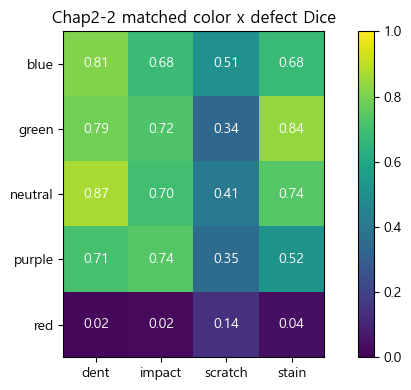

In [5]:
pivot = matched.pivot_table(index="color_group", columns="defect_type", values="target_dice", aggfunc="mean")
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", color="white")
ax.set_title("Chap2-2 matched color x defect Dice")
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(paths.runs_root / "factor_effects" / "matched_color_defect_heatmap.png", dpi=150)
plt.show()

## 25-5. 결론 문장 생성

In [6]:
color_table = matched_effects["color"].sort_values("mean", ascending=False)
defect_table = matched_effects["defect"].sort_values("mean", ascending=False)
shape_table = matched_effects["shape"].sort_values("mean", ascending=False)
report = [
    "# Chap2-2 factor analysis",
    "",
    f"Matched eval seeds: {matched['model_seed'].nunique()}",
    f"Best color: {color_table.iloc[0]['color_group']} Dice={color_table.iloc[0]['mean']:.3f}",
    f"Worst color: {color_table.iloc[-1]['color_group']} Dice={color_table.iloc[-1]['mean']:.3f}",
    f"Best defect: {defect_table.iloc[0]['defect_type']} Dice={defect_table.iloc[0]['mean']:.3f}",
    f"Worst defect: {defect_table.iloc[-1]['defect_type']} Dice={defect_table.iloc[-1]['mean']:.3f}",
    f"Shape gap: {shape_table.iloc[0]['mean'] - shape_table.iloc[-1]['mean']:.3f}",
    "",
    "See matched_factor_tests.csv for seed-level paired bootstrap decisions.",
]
out = paths.runs_root / "chap2_2_factor_analysis_report.md"
out.write_text("\n".join(report), encoding="utf-8")
print(out)
print("\n".join(report))

C:\Users\준승\Desktop\2026-1\Study\Deeplearning\Vision 응용\2-2장\runs\chap2_2_factor_analysis_report.md
# Chap2-2 factor analysis

Matched eval seeds: 3
Best color: neutral Dice=0.679
Worst color: red Dice=0.057
Best defect: dent Dice=0.639
Worst defect: scratch Dice=0.350
Shape gap: 0.000

See matched_factor_tests.csv for seed-level paired bootstrap decisions.
